# Modelos Agrupacion Macrogrupos

In [1]:
import sys
import os
import importlib
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


import src.features.preprocessing_4classes as prep
importlib.reload(prep) 
df, X, y = prep.preprocessing()

df.head(5)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,es_muy_larga,genre_grouped_4
0,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,False,other
1,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,False,other
2,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,False,other
3,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,False,other
4,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,False,other


In [2]:
from src.models.compare_models import compare_models

results = compare_models(X, y)

Entrenando Logistic Regression...
Entrenando Random Forest...
Entrenando Gradient Boosting...
Entrenando KNN...
Entrenando LightGBM...


In [3]:
import pandas as pd

summary = []

for model_name, result in results.items():
    report = result["report"]
    summary.append({
        "Modelo": model_name,
        "Accuracy": report["accuracy"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    })

# Ordenar por lo que definiste como prioridad
summary_df = pd.DataFrame(summary).sort_values(
    by=["Macro Recall", "Macro F1"], 
    ascending=False
)

summary_df

,Modelo,Accuracy,Macro Recall,Macro F1,Weighted F1
4,LightGBM,0.685128,0.686693,0.685224,0.687225
1,Random Forest,0.669652,0.672555,0.670267,0.671657
2,Gradient Boosting,0.666595,0.669121,0.666128,0.668400
3,KNN,0.580472,0.582536,0.581415,0.582739
0,Logistic Regression,0.562068,0.565240,0.559312,0.563628


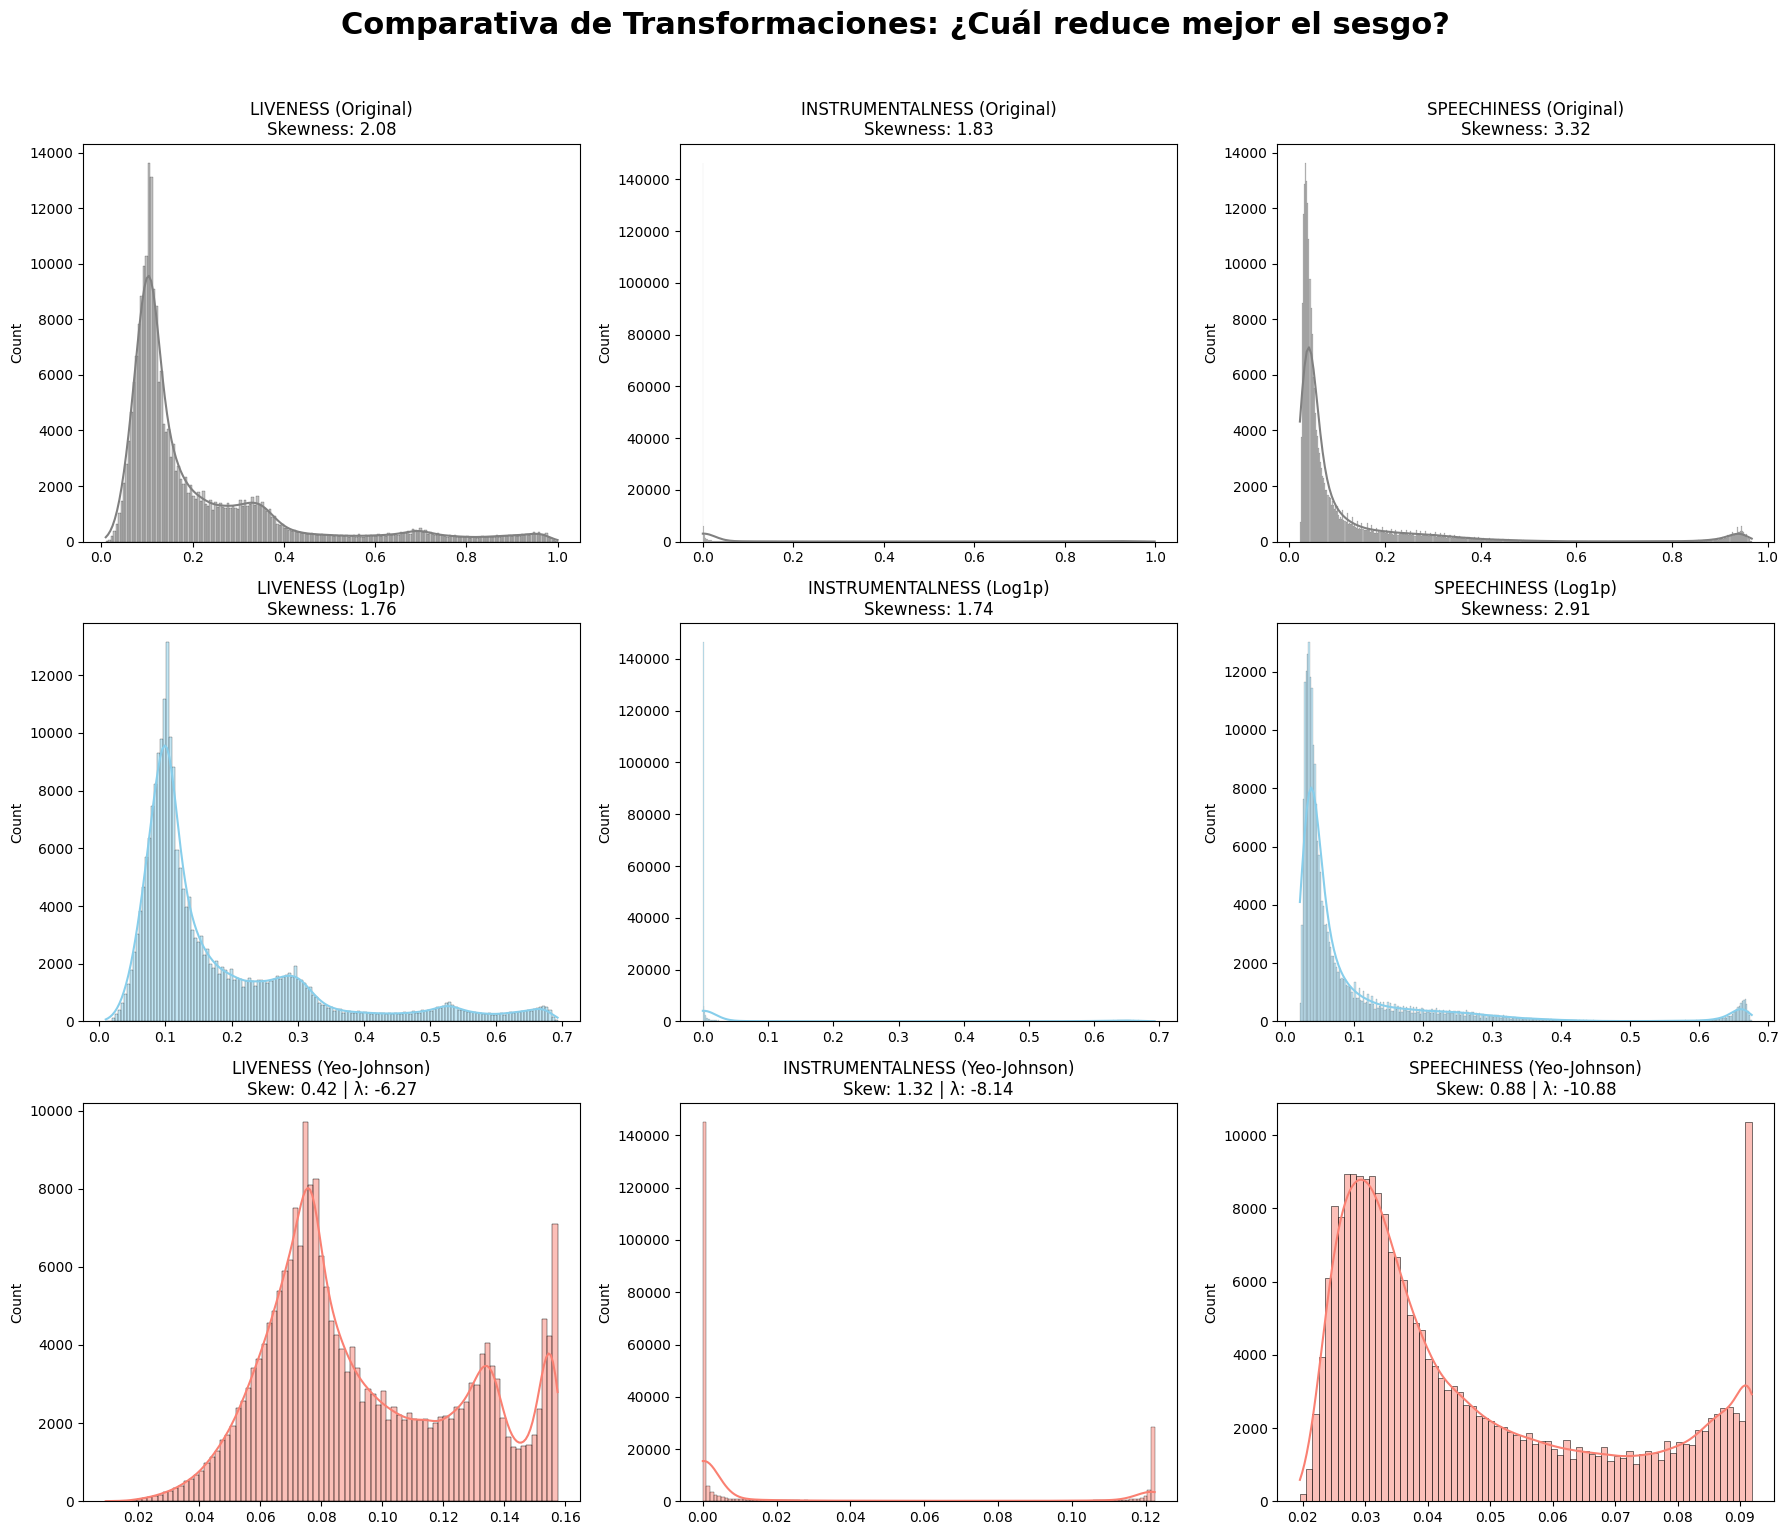

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def test_transformations(df):
    cols = ['liveness', 'instrumentalness', 'speechiness']
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
    for i, col in enumerate(cols):

        raw_data = df[col].values
        
        sns.histplot(raw_data, kde=True, ax=axes[0, i], color='gray')
        axes[0, i].set_title(f'{col.upper()} (Original)\nSkewness: {stats.skew(raw_data):.2f}')

        log_data = np.log1p(raw_data)
        sns.histplot(log_data, kde=True, ax=axes[1, i], color='skyblue')
        axes[1, i].set_title(f'{col.upper()} (Log1p)\nSkewness: {stats.skew(log_data):.2f}')
        
        yj_data, lmbda = stats.yeojohnson(raw_data)
        sns.histplot(yj_data, kde=True, ax=axes[2, i], color='salmon')
        axes[2, i].set_title(f'{col.upper()} (Yeo-Johnson)\nSkew: {stats.skew(yj_data):.2f} | λ: {lmbda:.2f}')

    plt.suptitle('Comparativa de Transformaciones: ¿Cuál reduce mejor el sesgo?', 
                 fontsize=22, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

test_transformations(df)

In [5]:
from sklearn.preprocessing import PowerTransformer

def apply_yeo_johnson(df):

    cols_to_transform = ['liveness', 'instrumentalness', 'speechiness']

    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    
    # 3. Ajustamos y transformamos los datos
    df[cols_to_transform] = pt.fit_transform(df[cols_to_transform])
    
    print("Yeo-Johnson aplicado y datos estandarizados.")
    return df, pt

df_final, transformer = apply_yeo_johnson(df)

Yeo-Johnson aplicado y datos estandarizados.


In [6]:
from src.models.compare_main_models import compare_main_models 

y = df['genre_grouped_4']

columnas_a_eliminar = ['genre_grouped_4'] 
X = df.drop(columns=columnas_a_eliminar)

print(f"Forma de X: {X.shape}")
print(f"Clases en y: {y.unique()}")


results_trans = compare_main_models(X, y)

Forma de X: (232282, 15)
Clases en y: ['other' 'mainstream' 'acoustic' 'urban']
Entrenando Gradient Boosting...
Entrenando LightGBM...
Entrenando XGBoost...


In [7]:
import pandas as pd

summary = []

for model_name, result in results_trans.items():
    report = result["report"]
    summary.append({
        "Modelo": model_name,
        "Accuracy": report["accuracy"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    })

# Ordenar por lo que definiste como prioridad
summary_df = pd.DataFrame(summary).sort_values(
    by=["Macro Recall", "Macro F1"], 
    ascending=False
)

summary_df

,Modelo,Accuracy,Macro Recall,Macro F1,Weighted F1
1,LightGBM,0.685623,0.687248,0.685866,0.687690
2,XGBoost,0.678671,0.681704,0.678886,0.680774
0,Gradient Boosting,0.666724,0.669150,0.666307,0.668510


El modelo mejoro muy poco, la transformacion no era uno de los que afectaban el modelo 

In [8]:
%load_ext autoreload
%autoreload 2

df['energy_dance'] = df['energy'] * df['danceability']
df['mood'] = df['valence'] * df['energy']
    

df['loud_energy'] = df['loudness'] * df['energy']
df['loud_dance'] = df['loudness'] * df['danceability']
    
y = df['genre_grouped_4']

columnas_a_eliminar = ['genre_grouped_4'] 
X = df.drop(columns=columnas_a_eliminar)

In [9]:
%load_ext autoreload
%autoreload 2


print(f"Forma de X: {X.shape}")
print(f"Clases en y: {y.unique()}")

results_union = compare_main_models(X, y)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Forma de X: (232282, 19)
Clases en y: ['other' 'mainstream' 'acoustic' 'urban']
Entrenando Gradient Boosting...
Entrenando LightGBM...
Entrenando XGBoost...


In [21]:
import pandas as pd

summary = []

for model_name, result in results_union.items():
    report = result["report"]
    summary.append({
        "Modelo": model_name,
        "Accuracy": report["accuracy"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    })

# Ordenar por lo que definiste como prioridad
summary_df = pd.DataFrame(summary).sort_values(
    by=["Macro Recall", "Macro F1"], 
    ascending=False
)

summary_df

,Modelo,Accuracy,Macro Recall,Macro F1,Weighted F1
1,LightGBM,0.686032,0.687388,0.686148,0.688132
2,XGBoost,0.678843,0.681624,0.678961,0.680912
0,Gradient Boosting,0.668877,0.671587,0.668497,0.670613


El modelo mejoro muy poco, pero es algo que ayuda solo un poco a la prediccion asi que lo dejamos 

### Intento hiperparametros Gradient Boosting 

Se intento hacer algunos ajustes a los hiperparametros para ver que tan efectivo es el modelo, pero no se ven un resultado efectivo

In [22]:
from src.models.gradient_boosting_2 import train_gradient_boosting_model
report_gradient_2 = train_gradient_boosting_model(X, y)

print(report_gradient_2[1])

{'acoustic': {'precision': 0.6407421289355323, 'recall': 0.6357973035797304, 'f1-score': 0.6382601390768656, 'support': 10755.0}, 'mainstream': {'precision': 0.6094057057667548, 'recall': 0.7000077839184246, 'f1-score': 0.6515722359078394, 'support': 12847.0}, 'other': {'precision': 0.8120904476234425, 'recall': 0.6358118361153262, 'f1-score': 0.7132203939369377, 'support': 13839.0}, 'urban': {'precision': 0.6321985676444619, 'recall': 0.7147293700088732, 'f1-score': 0.6709354989848508, 'support': 9016.0}, 'accuracy': 0.6688765955614869, 'macro avg': {'precision': 0.6736092124925479, 'recall': 0.6715865734055886, 'f1-score': 0.6684970669766235, 'support': 46457.0}, 'weighted avg': {'precision': 0.6814611078896708, 'recall': 0.6688765955614869, 'f1-score': 0.6706125621762146, 'support': 46457.0}}


In [16]:
from src.models.gradient_boosting_2 import train_gradient_boosting_model
import pandas as pd

report_gradient_2 = train_gradient_boosting_model(X, y)
report = report_gradient_2[1]

summary_df = pd.DataFrame([{
    "Modelo": "Gradient Boosting",
    "Accuracy": report["accuracy"],
    "Macro Recall": report["macro avg"]["recall"],
    "Macro F1": report["macro avg"]["f1-score"],
    "Weighted F1": report["weighted avg"]["f1-score"]
}])

summary_df

,Modelo,Accuracy,Macro Recall,Macro F1,Weighted F1
0,Gradient Boosting,0.668877,0.671587,0.668497,0.670613


### Probamos Modelo XGBoost 

Se prueba con un modelo XGBoost a ver si mejoran las metricas del modelo, se puede ver que el modelo mejora unas decimas. 

In [13]:
from src.models.XGBoost import train_xgboost_model
report_xgboost = train_gradient_boosting_model(X, y)


In [15]:
import pandas as pd

report = report_xgboost[1]

df_results = pd.DataFrame(report).transpose()

# reset index para que el nombre de clase sea columna
df_results = df.reset_index().rename(columns={'index': 'Clase'})

df_results

,Clase,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,...,speechiness,tempo,time_signature,valence,es_muy_larga,genre_grouped_4,energy_dance,mood,loud_energy,loud_dance
0,0,0,0.61100,0.389,99373,0.910,-0.583269,C#,1.242733,-1.828,...,-0.348999,166.969,4/4,0.814,False,other,0.353990,0.740740,-1.663480,-0.711092
1,1,1,0.24600,0.590,137373,0.737,-0.583269,F#,-0.030589,-5.559,...,0.369276,174.003,4/4,0.816,False,other,0.434830,0.601392,-4.096983,-3.279810
2,2,3,0.95200,0.663,170267,0.131,-0.583269,C,-0.654041,-13.879,...,-0.800309,99.488,5/4,0.368,False,other,0.086853,0.048208,-1.818149,-9.201777
3,3,0,0.70300,0.240,152427,0.326,-0.583269,C#,-0.723098,-12.178,...,-0.702053,171.758,4/4,0.227,False,other,0.078240,0.074002,-3.970028,-2.922720
4,4,4,0.95000,0.331,82625,0.225,0.999148,F,0.454166,-21.150,...,-0.529892,140.576,4/4,0.390,False,other,0.074475,0.087750,-4.758750,-7.000650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232277,232277,39,0.00384,0.687,326240,0.714,1.931537,D,-0.951619,-10.626,...,-0.943625,115.542,4/4,0.962,False,mainstream,0.490518,0.686868,-7.586964,-7.300062
232278,232278,38,0.03290,0.785,282447,0.683,-0.564796,E,0.709767,-6.944,...,-0.877258,113.830,4/4,0.969,False,mainstream,0.536155,0.661827,-4.742752,-5.451040
232279,232279,47,0.90100,0.517,166960,0.419,-0.583269,D,-0.786233,-8.282,...,1.141842,84.135,4/4,0.813,False,mainstream,0.216623,0.340647,-3.470158,-4.281794
232280,232280,44,0.26200,0.745,222442,0.704,-0.583269,A,1.194828,-7.137,...,1.123683,100.031,4/4,0.489,False,mainstream,0.524480,0.344256,-5.024448,-5.317065


## Eliminar Variables 

Eliminamos las siguientes variables para confirmar si ayudan a la mejora del modelo 

In [17]:
cols_to_drop = ['duration_ms', 'genre_grouped_4']

X_eliminated = df.drop(columns=cols_to_drop, errors='ignore')
y = df['genre_grouped_4']

report_xgboost = train_gradient_boosting_model(X_eliminated, y)


In [18]:
report_xgboost[1]

{'acoustic': {'precision': 0.6279742465242139,
  'recall': 0.6257554625755463,
  'f1-score': 0.6268628912071535,
  'support': 10755.0},
 'mainstream': {'precision': 0.6040034812880766,
  'recall': 0.7022651202615396,
  'f1-score': 0.6494385257702274,
  'support': 12847.0},
 'other': {'precision': 0.8070543374642517,
  'recall': 0.6117494038586603,
  'f1-score': 0.6959595544412018,
  'support': 13839.0},
 'urban': {'precision': 0.620866867060991,
  'recall': 0.7101818988464951,
  'f1-score': 0.6625278079569559,
  'support': 9016.0},
 'accuracy': 0.6591256430677831,
 'macro avg': {'precision': 0.6649747330843833,
  'recall': 0.6624879713855603,
  'f1-score': 0.6586971948438847,
  'support': 46457.0},
 'weighted avg': {'precision': 0.6733120174584135,
  'recall': 0.6591256430677831,
  'f1-score': 0.6606105027434994,
  'support': 46457.0}}

In [19]:
import pandas as pd

report = report_xgboost[1]

df_results = pd.DataFrame(report).transpose()

# reset index para que el nombre de clase sea columna
df_results = df_results.reset_index().rename(columns={'index': 'Clase'})

df_results

,Clase,precision,recall,f1-score,support
0,acoustic,0.627974,0.625755,0.626863,10755.000000
1,mainstream,0.604003,0.702265,0.649439,12847.000000
2,other,0.807054,0.611749,0.695960,13839.000000
3,urban,0.620867,0.710182,0.662528,9016.000000
4,accuracy,0.659126,0.659126,0.659126,0.659126
5,macro avg,0.664975,0.662488,0.658697,46457.000000
6,weighted avg,0.673312,0.659126,0.660611,46457.000000


In [20]:
from src.models.tune_best_model import tune_lightgbm

best_model, best_params, report, metrics = tune_lightgbm(X_eliminated, y, n_iter=20, cv=3)

Buscando mejores hiperparámetros (20 combinaciones, 3 folds)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores parámetros encontrados:
  classifier__colsample_bytree: 0.6227122864881435
  classifier__learning_rate: 0.04539154139343447
  classifier__max_depth: 7
  classifier__min_child_samples: 48
  classifier__n_estimators: 585
  classifier__num_leaves: 32
  classifier__reg_alpha: 0.15043915490838483
  classifier__reg_lambda: 1.0696809887549352
  classifier__subsample: 0.6129104315740864

Resultados en test:
  F1 Macro:    0.6749
  F1 Weighted: 0.6771
  Accuracy:    0.6754

Diagnóstico: OK — modelo bien calibrado
